In [ ]:
import torch
from diffusers import AutoencoderKL
import matplotlib.pyplot as plt

# Set device to CPU
device = torch.device("cpu")

# Load a pretrained VAE model on CPU
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device)

In [3]:
from torchvision import transforms
from PIL import Image

In [4]:
# Load and preprocess an image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((512, 512)),  # Resize to match the VAE input size
        transforms.ToTensor(),          # Convert to tensor (C, H, W)
        transforms.Normalize([0.5], [0.5])  # Normalize to [-1, 1]
    ])
    img = Image.open(image_path).convert("RGB")
    return transform(img).unsqueeze(0)  # Add batch dimension

Latent vector shape: torch.Size([1, 4, 64, 64])


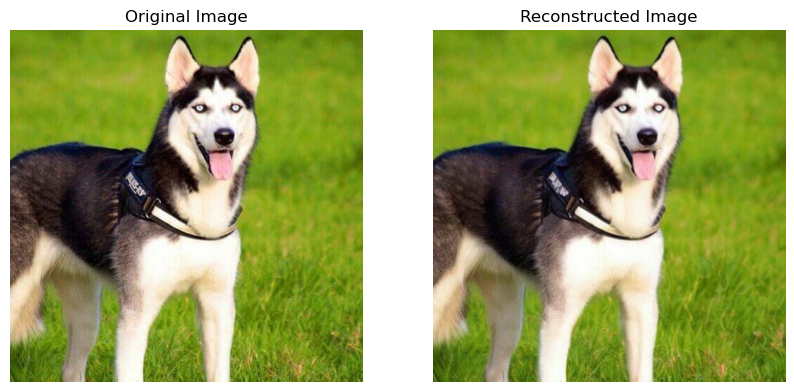

In [6]:

# input_dir = '/data_dir/test/huskies_no_snow/husky1.jpg'
# latent_vector = vae.encode(input_image)





image_path = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/huskies_no_snow/husky1.jpg'

# Preprocess image
input_image = preprocess_image(image_path).to(device)

# Encode image into latent space
with torch.no_grad():
    latent_vector = vae.encode(input_image).latent_dist.sample()

print("Latent vector shape:", latent_vector.shape)  # (1, 4, 64, 64) for 512x512 input

# Decode latent space to reconstruct the image
with torch.no_grad():
    reconstructed_image = vae.decode(latent_vector).sample

# Convert the tensor back to an image
def tensor_to_image(tensor):
    tensor = tensor.squeeze(0).cpu().permute(1, 2, 0)  # Remove batch dim and reorder channels
    tensor = (tensor * 0.5 + 0.5).clamp(0, 1)  # De-normalize to [0,1]
    return tensor.numpy()

# Display original and reconstructed image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original Image
ax[0].imshow(Image.open(image_path))
ax[0].set_title("Original Image")
ax[0].axis("off")

# Reconstructed Image
ax[1].imshow(tensor_to_image(reconstructed_image))
ax[1].set_title("Reconstructed Image")
ax[1].axis("off")

plt.show()





Latent vector shape: torch.Size([1, 4, 64, 64])


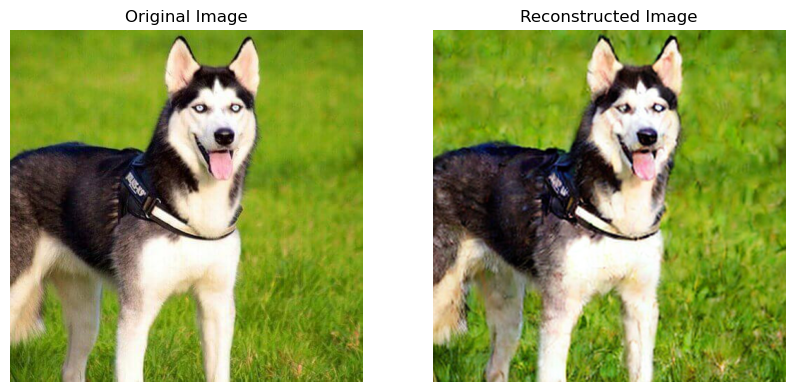

In [9]:




image_path = f'/home/bipar001/anaconda3/python_test/huskyvswolf/ModelAugmentation/src/data_dir/train/huskies_no_snow/husky1.jpg'

# Preprocess image
input_image = preprocess_image(image_path).to(device)

# Encode image into latent space
with torch.no_grad():
    latent_vector = vae.encode(input_image).latent_dist.sample()

print("Latent vector shape:", latent_vector.shape)  # (1, 4, 64, 64) for 512x512 input
noise_toadd = 1.5 * torch.randn((1, 4, 64, 64), device=device)
latent_vector += noise_toadd
# Decode latent space to reconstruct the image
with torch.no_grad():
    reconstructed_image = vae.decode(latent_vector).sample

# Convert the tensor back to an image
def tensor_to_image(tensor):
    tensor = tensor.squeeze(0).cpu().permute(1, 2, 0)  # Remove batch dim and reorder channels
    tensor = (tensor * 0.5 + 0.5).clamp(0, 1)  # De-normalize to [0,1]
    return tensor.numpy()

# Display original and reconstructed image
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original Image
ax[0].imshow(Image.open(image_path))
ax[0].set_title("Original Image")
ax[0].axis("off")

# Reconstructed Image
ax[1].imshow(tensor_to_image(reconstructed_image))
ax[1].set_title("Reconstructed Image")
ax[1].axis("off")

plt.show()

In [ ]:
# Example: Create a random latent vector
latent_vector = torch.randn((1, 4, 64, 64), device=device)

# Decode the latent vector (output will also be on CPU)
reconstructed_image = vae.decode(latent_vector).sample

print("Reconstruction complete. Output is on:", reconstructed_image.device)

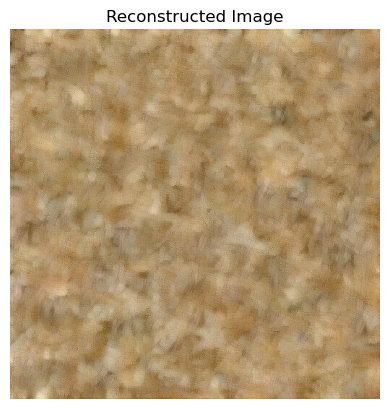

In [2]:
import matplotlib.pyplot as plt


# Convert the tensor to a NumPy array
reconstructed_image = reconstructed_image.detach().cpu().numpy()  # Move to CPU if needed

# The model output might be in (batch, channels, height, width) format
# So, remove batch dimension and rearrange channels if necessary
reconstructed_image = reconstructed_image[0].transpose(1, 2, 0)  # Convert (C, H, W) → (H, W, C)

# Clip values to [0,1] if they are out of range (some models output values beyond this)
reconstructed_image = (reconstructed_image - reconstructed_image.min()) / (reconstructed_image.max() - reconstructed_image.min())

# Display the image
plt.imshow(reconstructed_image)
plt.axis("off")  # Hide axes
plt.title("Reconstructed Image")
plt.show()
